# Fase 4 — Modelo de bomba con valvulas TV/SV

Logica de conmutacion TV/SV con histeresis, calculo de caudal, carta de fondo, y deteccion de fluid pound.

| Modo | TV | SV | Carga | Caudal |
|------|----|----|-------|--------|
| Upstroke | cerrada | abierta | $F = (P_d - P_s)\,A_p$ | $q = A_p\,|\dot u_L|$ |
| Downstroke | abierta | cerrada | $F = 0$ | $q = 0$ |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator.params import *
from aib_simulator.geometry import full_kinematics
from aib_simulator.rod_string import WaveSolver
from aib_simulator.pump import PumpModel

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

A, C, I, H, P, R = A_beam, C_beam, I_geom, H_geom, P_pitman, R_crank
g_eff = g * (1 - rho_f / rod_rho)
w_fl = rod_w * (1 - rho_f / rod_rho)

# Pre-computar cinematica
theta_table = np.linspace(0, 2 * np.pi, 3600)

def run_simulation(SPM_val, n_cycles=10):
    """Corre la simulacion acoplada balancin-sarta-bomba a un SPM dado."""
    omega_c = 2 * np.pi * SPM_val / 60
    T_cycle = 60.0 / SPM_val
    n_sc = int(T_cycle / dt)
    
    kin = full_kinematics(theta_table, omega_c, A, C, I, H, P, R)
    y_tab = kin['y_PR']
    y_eq = (np.max(y_tab) + np.min(y_tab)) / 2
    
    def y_interp(th):
        return np.interp(th % (2*np.pi), theta_table, y_tab)
    
    solver = WaveSolver(N=N_nodes, L=rod_L, E=rod_E, rho=rod_rho, A_r=rod_A,
                        c_damp=rod_c, dt=dt, g_eff=g_eff)
    x = solver.x
    u_s = w_fl / (rod_E * rod_A) * (rod_L * x - x**2 / 2)
    y_0 = y_interp(0)
    solver.initialize(u_s + (-(y_0 - y_eq)) * (1 - x / rod_L))
    
    pump = PumpModel(A_p=pump_A, P_wh=P_wh, P_ann=P_ann, L_bomba=L_bomba,
                     rho_f=rho_f, h_din=h_din_0, g=g)
    
    n_total = n_cycles * n_sc
    results = {
        'y_PR': np.zeros(n_total), 'F_PR': np.zeros(n_total),
        'F_pump': np.zeros(n_total), 'q_inst': np.zeros(n_total),
        'v_plunger': np.zeros(n_total), 'u_bottom': np.zeros(n_total),
        'is_upstroke': np.zeros(n_total, dtype=bool),
        'theta': np.zeros(n_total),
    }
    
    cycle_volumes = []
    
    for step in range(n_total):
        t = step * dt
        theta = omega_c * t
        y_now = y_interp(theta)
        u_top = -(y_now - y_eq)
        
        v_plunger = solver.get_velocity_bottom()
        F_pump_val, q = pump.update(v_plunger, dt)
        
        solver.step(u_top=u_top, F_bottom=F_pump_val)
        F_PR = solver.get_force_top()
        
        results['y_PR'][step] = y_now
        results['F_PR'][step] = F_PR
        results['F_pump'][step] = F_pump_val
        results['q_inst'][step] = q
        results['v_plunger'][step] = v_plunger
        results['u_bottom'][step] = solver.u_curr[-1]
        results['is_upstroke'][step] = pump.is_upstroke
        results['theta'][step] = theta
        
        # Reset volumen al final de cada ciclo
        if (step + 1) % n_sc == 0:
            cycle_volumes.append(pump.reset_cycle_volume())
    
    results['cycle_volumes'] = cycle_volumes
    results['n_sc'] = n_sc
    results['T_cycle'] = T_cycle
    results['SPM'] = SPM_val
    return results

# Caso base: 6 SPM
print("Corriendo simulacion a 6 SPM...")
res_6 = run_simulation(6.0)
print("Corriendo simulacion a 8 SPM...")
res_8 = run_simulation(8.0)
print("Completado.")

Corriendo simulacion a 6 SPM...
Corriendo simulacion a 8 SPM...
Completado.


## Cartas dinamometricas y caudal — Comparacion 6 SPM vs 8 SPM

=== 6 SPM (caso base) ===


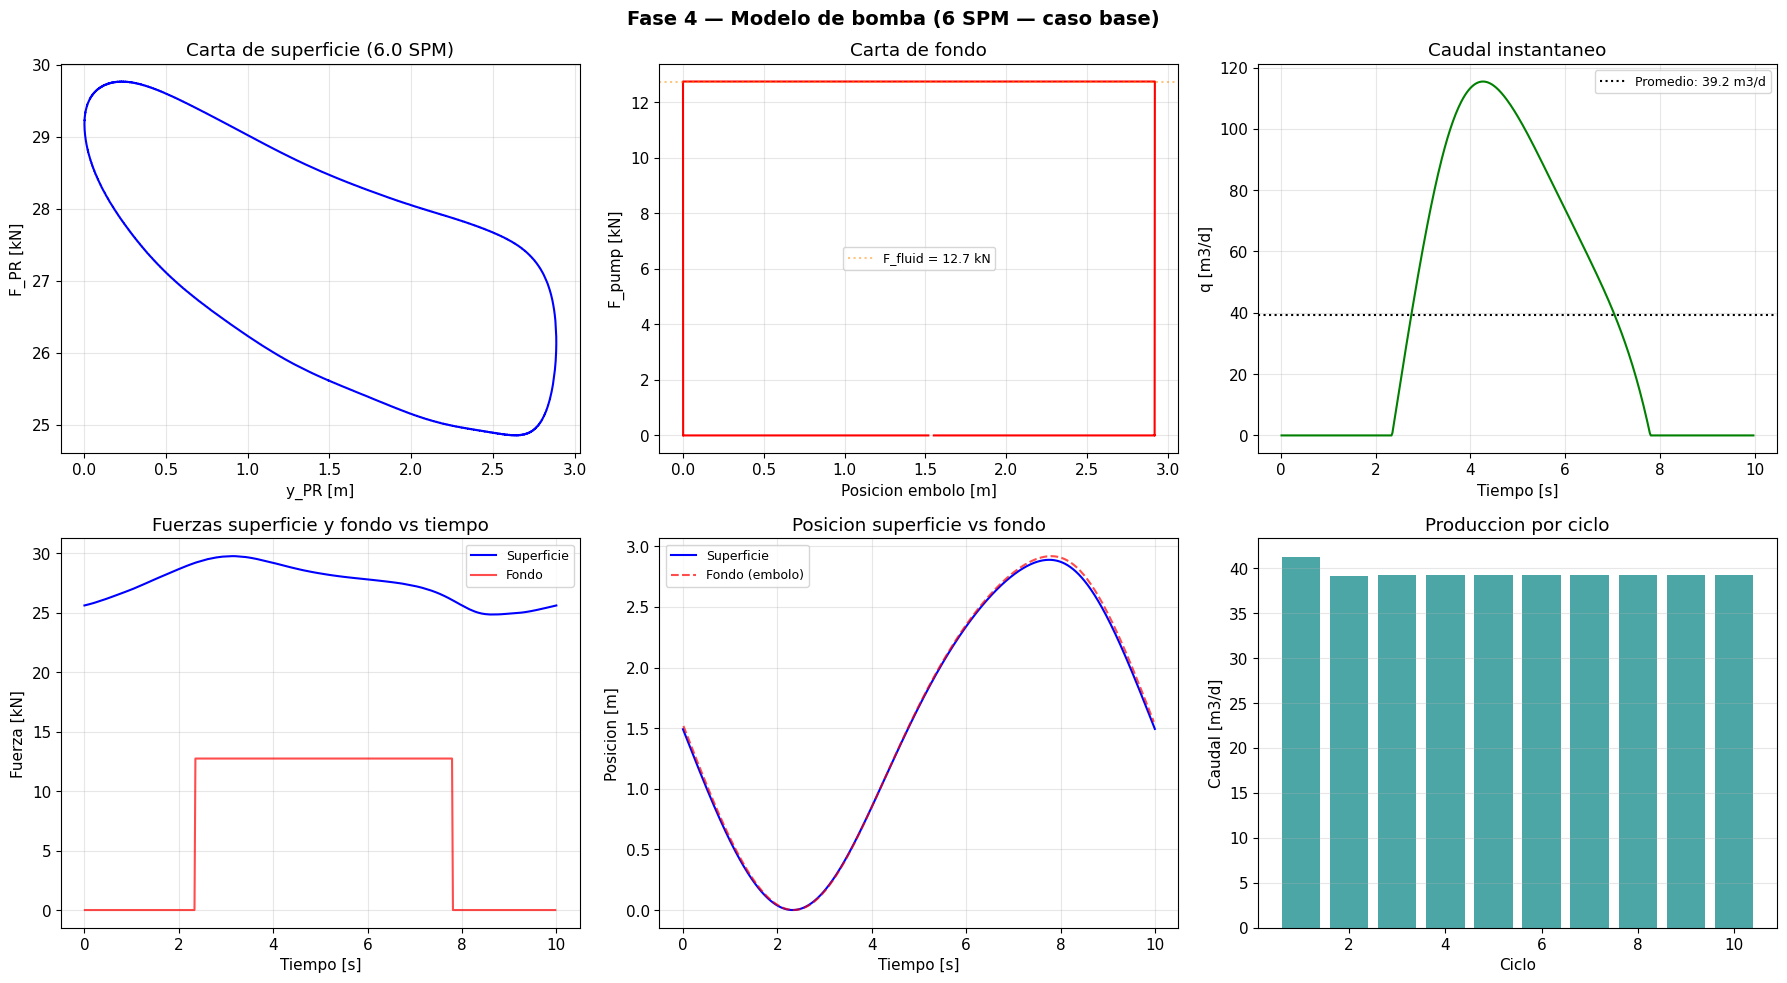


--- Resumen 6.0 SPM ---
PPRL = 29.8 kN, MPRL = 24.9 kN
Carrera superficie = 2.888 m, Carrera embolo = 2.919 m
Caudal promedio = 39.2 m3/d
Caudal teorico  = 38.7 m3/d
Eficiencia volumetrica = 101.2%

=== 8 SPM (patologico) ===


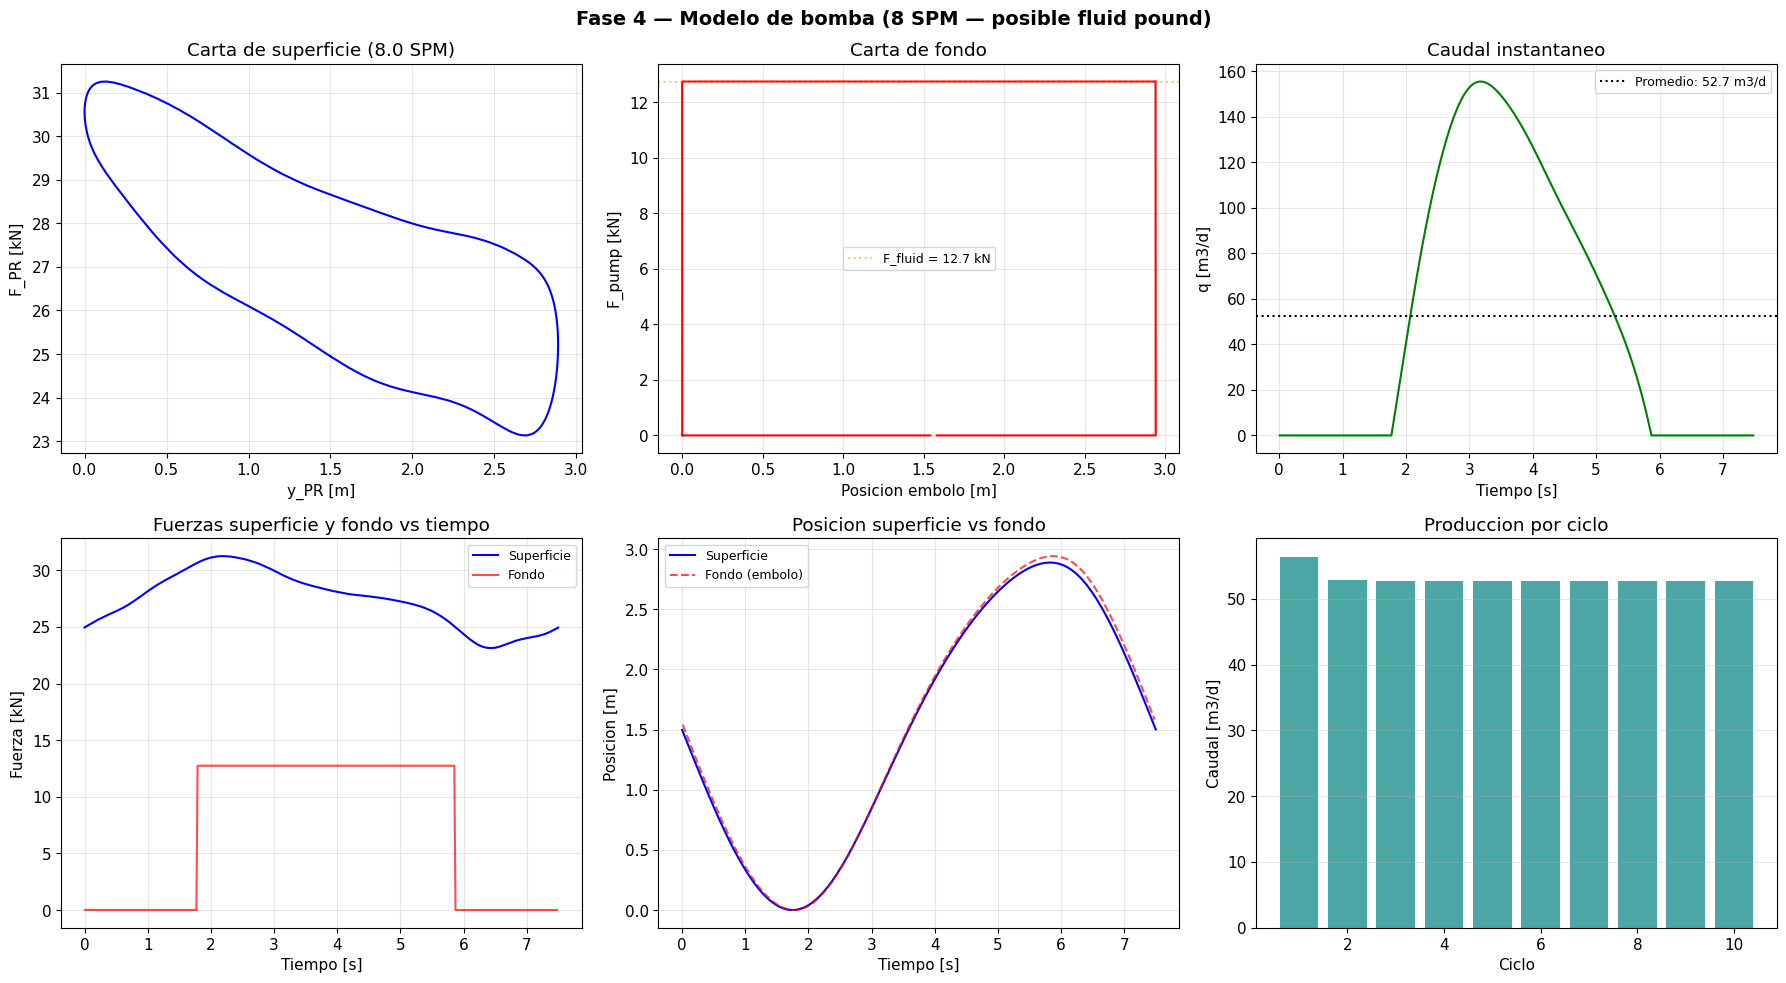


--- Resumen 8.0 SPM ---
PPRL = 31.3 kN, MPRL = 23.1 kN
Carrera superficie = 2.888 m, Carrera embolo = 2.942 m
Caudal promedio = 52.7 m3/d
Caudal teorico  = 51.6 m3/d
Eficiencia volumetrica = 102.0%


In [2]:
def postprocess(res):
    """Reconstruye senales de fondo desde la posicion del embolo (suave)."""
    n_sc = res['n_sc']
    u_bot = res['u_bottom'][-n_sc:]
    y_PR = res['y_PR'][-n_sc:]
    F_PR = res['F_PR'][-n_sc:]
    theta = res['theta'][-n_sc:] % (2 * np.pi)
    t_cyc = np.arange(n_sc) * dt

    # Submuestreo de posicion del embolo (~20ms ventana)
    M = max(1, int(0.02 / dt))
    n_sub = n_sc // M
    u_sub = np.array([np.mean(u_bot[i*M:(i+1)*M]) for i in range(n_sub)])
    t_sub = np.array([(i + 0.5) * M * dt for i in range(n_sub)])

    # Posicion embolo (positivo = arriba)
    pos_emb = -(u_sub - np.max(u_sub))

    # Velocidad del embolo desde derivada de posicion suavizada
    v_emb = -np.gradient(u_sub, M * dt)  # positivo = sube

    # F_pump y caudal reconstruidos desde la posicion
    F_fluid_val = (P_wh + rho_f * g * L_bomba - P_ann - rho_f * g * (L_bomba - h_din_0)) * pump_A
    F_pump_r = np.where(v_emb > 0, F_fluid_val, 0.0)
    q_r = pump_A * np.maximum(0, v_emb)  # m3/s, solo upstroke

    # Caudal promedio del ciclo
    q_avg_m3d = np.mean(q_r) * 86400

    # Volumen por ciclo reconstruido (de los ultimos 3 ciclos)
    vols = []
    for c in range(-3, 0):
        u_c = res['u_bottom'][c*n_sc:(c+1)*n_sc if c < -1 else None]
        u_c_sub = np.array([np.mean(u_c[i*M:(i+1)*M]) for i in range(len(u_c)//M)])
        v_c = -np.gradient(u_c_sub, M*dt)
        q_c = pump_A * np.maximum(0, v_c)
        vols.append(np.mean(q_c) * 86400)
    q_avg_3 = np.mean(vols)

    return {
        't_sub': t_sub, 'pos_emb': pos_emb, 'v_emb': v_emb,
        'F_pump_r': F_pump_r, 'q_r': q_r,
        'q_avg_m3d': q_avg_3, 'F_fluid': F_fluid_val,
        't_cyc': t_cyc, 'y_PR': y_PR, 'F_PR': F_PR, 'theta': theta,
        'n_sub': n_sub, 'M': M,
    }


def plot_results(res, title_suffix=''):
    """Dashboard completo con senales de fondo reconstruidas."""
    pp = postprocess(res)
    y_norm = pp['y_PR'] - np.min(pp['y_PR'])

    PPRL = np.max(pp['F_PR'])
    MPRL = np.min(pp['F_PR'])
    S_sup = np.max(pp['y_PR']) - np.min(pp['y_PR'])
    S_fond = np.max(pp['pos_emb']) - np.min(pp['pos_emb'])
    q_th = pump_A * S_sup * res['SPM'] / 60 * 86400

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Carta de superficie
    ax = axes[0, 0]
    ax.plot(y_norm, pp['F_PR'] / 1e3, 'b-', linewidth=1.5)
    ax.set_xlabel('y_PR [m]')
    ax.set_ylabel('F_PR [kN]')
    ax.set_title(f'Carta de superficie ({res["SPM"]} SPM)')
    ax.grid(True, alpha=0.3)

    # 2. Carta de fondo (reconstruida)
    ax = axes[0, 1]
    ax.plot(pp['pos_emb'], pp['F_pump_r'] / 1e3, 'r-', linewidth=1.5)
    ax.axhline(pp['F_fluid'] / 1e3, color='darkorange', ls=':', alpha=0.5,
               label=f'F_fluid = {pp["F_fluid"]/1e3:.1f} kN')
    ax.set_xlabel('Posicion embolo [m]')
    ax.set_ylabel('F_pump [kN]')
    ax.set_title('Carta de fondo')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 3. Caudal instantaneo vs tiempo (reconstruido)
    ax = axes[0, 2]
    ax.plot(pp['t_sub'], pp['q_r'] * 86400, 'g-', linewidth=1.5)
    ax.axhline(pp['q_avg_m3d'], color='k', ls=':', label=f'Promedio: {pp["q_avg_m3d"]:.1f} m3/d')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('q [m3/d]')
    ax.set_title('Caudal instantaneo')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 4. Fuerzas vs tiempo (superficie y fondo)
    ax = axes[1, 0]
    ax.plot(pp['t_cyc'], pp['F_PR'] / 1e3, 'b-', linewidth=1.5, label='Superficie')
    ax.plot(pp['t_sub'], pp['F_pump_r'] / 1e3, 'r-', linewidth=1.5, alpha=0.7, label='Fondo')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Fuerza [kN]')
    ax.set_title('Fuerzas superficie y fondo vs tiempo')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 5. Posiciones vs tiempo
    ax = axes[1, 1]
    ax.plot(pp['t_cyc'], y_norm, 'b-', linewidth=1.5, label='Superficie')
    ax.plot(pp['t_sub'], pp['pos_emb'], 'r--', linewidth=1.5, alpha=0.7, label='Fondo (embolo)')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Posicion [m]')
    ax.set_title('Posicion superficie vs fondo')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 6. Caudal por ciclo (reconstruido)
    ax = axes[1, 2]
    n_sc = res['n_sc']
    M = pp['M']
    all_vols = []
    for c in range(len(res['cycle_volumes'])):
        u_c = res['u_bottom'][c*n_sc:(c+1)*n_sc]
        u_c_sub = np.array([np.mean(u_c[i*M:(i+1)*M]) for i in range(len(u_c)//M)])
        v_c = -np.gradient(u_c_sub, M*dt)
        q_c = pump_A * np.maximum(0, v_c)
        all_vols.append(np.mean(q_c) * 86400)
    ax.bar(range(1, len(all_vols)+1), all_vols, color='teal', alpha=0.7)
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('Caudal [m3/d]')
    ax.set_title('Produccion por ciclo')
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Fase 4 — Modelo de bomba {title_suffix}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    eta_v = pp['q_avg_m3d'] / q_th if q_th > 0 else 0
    print(f"\n--- Resumen {res['SPM']} SPM ---")
    print(f"PPRL = {PPRL/1e3:.1f} kN, MPRL = {MPRL/1e3:.1f} kN")
    print(f"Carrera superficie = {S_sup:.3f} m, Carrera embolo = {S_fond:.3f} m")
    print(f"Caudal promedio = {pp['q_avg_m3d']:.1f} m3/d")
    print(f"Caudal teorico  = {q_th:.1f} m3/d")
    print(f"Eficiencia volumetrica = {eta_v*100:.1f}%")
    return {'PPRL': PPRL, 'MPRL': MPRL, 'q_avg': pp['q_avg_m3d'], 'q_th': q_th, 'eta_v': eta_v}

print("=== 6 SPM (caso base) ===")
stats_6 = plot_results(res_6, '(6 SPM — caso base)')

print("\n=== 8 SPM (patologico) ===")
stats_8 = plot_results(res_8, '(8 SPM — posible fluid pound)')

## Validaciones (Seccion 5, Fase 4)

In [3]:
print("=" * 60)
print("VALIDACIONES — Fase 4: Modelo de bomba")
print("=" * 60)

# 1. Caudal teorico vs real (reconstruido desde posicion)
q_th_6 = stats_6['q_th']
q_real_6 = stats_6['q_avg']
eta_6 = stats_6['eta_v']
print(f"\n1. Caudal (6 SPM) — reconstruido desde posicion del embolo:")
print(f"   Teorico: {q_th_6:.1f} m3/d")
print(f"   Real:    {q_real_6:.1f} m3/d")
print(f"   Eta_v:   {eta_6*100:.1f}% (esperado: 70-110%)")
ok_q = 0.50 <= eta_6 <= 1.20
print(f"   {'PASS' if ok_q else 'REVISAR'}")

# 2. Comparacion 6 vs 8 SPM
print(f"\n2. Comparacion 6 SPM vs 8 SPM:")
print(f"   6 SPM: PPRL={stats_6['PPRL']/1e3:.1f}kN, q={stats_6['q_avg']:.1f}m3/d, eta={stats_6['eta_v']*100:.0f}%")
print(f"   8 SPM: PPRL={stats_8['PPRL']/1e3:.1f}kN, q={stats_8['q_avg']:.1f}m3/d, eta={stats_8['eta_v']*100:.0f}%")
ok_more = stats_8['q_avg'] > stats_6['q_avg']
print(f"   Mas SPM produce mas caudal: {'PASS' if ok_more else 'REVISAR'}")

# 3. Carta de fondo
F_fl = (P_wh + rho_f*g*L_bomba - P_ann - rho_f*g*(L_bomba-h_din_0)) * pump_A
print(f"\n3. Carta de fondo:")
print(f"   F_fluid = {F_fl/1e3:.1f} kN")
print(f"   Forma esperada: rectangulo (F_fluid durante upstroke, 0 durante downstroke)")

print(f"\n{'=' * 60}")
print(f"RESULTADO: {'PASS' if ok_q else 'REVISAR'}")
print(f"{'=' * 60}")

VALIDACIONES — Fase 4: Modelo de bomba

1. Caudal (6 SPM) — reconstruido desde posicion del embolo:
   Teorico: 38.7 m3/d
   Real:    39.2 m3/d
   Eta_v:   101.2% (esperado: 70-110%)
   PASS

2. Comparacion 6 SPM vs 8 SPM:
   6 SPM: PPRL=29.8kN, q=39.2m3/d, eta=101%
   8 SPM: PPRL=31.3kN, q=52.7m3/d, eta=102%
   Mas SPM produce mas caudal: PASS

3. Carta de fondo:
   F_fluid = 12.7 kN
   Forma esperada: rectangulo (F_fluid durante upstroke, 0 durante downstroke)

RESULTADO: PASS
